# Análise de Dados - Identificação de Amostras Difíceis de Classificar

Este notebook analisa o conjunto de dados `train_5fold.csv` para identificar:
- Amostras com alta incerteza (difíceis de classificar)
- Padrões de erro nos modelos
- Distribuição de classes e instituições
- Possíveis ruídos nos rótulos

In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from torchvision.models import efficientnet_b0, efficientnet_b1, efficientnet_b2, efficientnet_b3
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B1_Weights, EfficientNet_B2_Weights, EfficientNet_B3_Weights

from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

# Configuração
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Carregamento e Exploração dos Dados

In [7]:
ROOT_DIR = '../../../..'
df = pd.read_csv(f"{ROOT_DIR}/dataset/train.csv")
df_train_val = pd.read_csv(f"../../../data/train_5fold.csv")
df.columns = df.columns.str.strip()

print(f"Total de amostras: {len(df)}")
print(f"\nColunas: {df.columns.tolist()}")
df.head(10)

Total de amostras: 10616

Colunas: ['image_id', 'data_provider', 'isup_grade', 'gleason_score']
                              image_id data_provider  isup_grade  \
0     aa9be7d9f82e983d21e2746078b877d9       radboud           4   
1     34a98ca2d4eb1a91e428bf2112e26543    karolinska           1   
2     95eeb46ecc4a9693119627fedb8df55c       radboud           4   
3     1df32b02eaa3cfad5d8c51a3e289cfc1       radboud           1   
4     ebb6d5ca45942536f78beb451ee43cc4       radboud           2   
...                                ...           ...         ...   
9019  c508dccd42708eb8dd47b39a6f1c2c3d    karolinska           1   
9020  fd8e22703f13041daec8ee1e560392a9    karolinska           2   
9021  53395078c052e6dcc08cbf8a227ba147    karolinska           1   
9022  b55955e9f9f6ff4787f5b78c18ae58db    karolinska           2   
9023  9bb08719f4422442cba4253b2ba34b62       radboud           0   

     gleason_score  fold  
0              4+4     0  
1              3+3     3  
2     

In [3]:
print("=" * 60)
print("ESTATÍSTICAS BÁSICAS")
print("=" * 60)

print("\n1. Distribuição por ISUP Grade:")
print(df['isup_grade'].value_counts().sort_index())
print(f"\nPercentual:")
print(df['isup_grade'].value_counts(normalize=True).sort_index() * 100)

print("\n2. Distribuição por Instituição:")
print(df['data_provider'].value_counts())

print("\n3. Distribuição por Gleason Score:")
print(df['gleason_score'].value_counts())

# print("\n4. Distribuição por Fold:")
# print(df['fold'].value_counts().sort_index())

ESTATÍSTICAS BÁSICAS

1. Distribuição por ISUP Grade:
isup_grade
0    2892
1    2666
2    1343
3    1242
4    1249
5    1224
Name: count, dtype: int64

Percentual:
isup_grade
0    27.241899
1    25.113037
2    12.650716
3    11.699322
4    11.765260
5    11.529766
Name: proportion, dtype: float64

2. Distribuição por Instituição:
data_provider
karolinska    5456
radboud       5160
Name: count, dtype: int64

3. Distribuição por Gleason Score:
gleason_score
3+3         2666
0+0         1925
3+4         1342
4+3         1243
4+4         1126
negative     967
4+5          849
5+4          248
5+5          127
3+5           80
5+3           43
Name: count, dtype: int64


In [8]:
print("=" * 60)
print("ESTATÍSTICAS BÁSICAS")
print("=" * 60)

print("\n1. Distribuição por ISUP Grade:")
print(df_train_val['isup_grade'].value_counts().sort_index())
print(f"\nPercentual:")
print(df_train_val['isup_grade'].value_counts(normalize=True).sort_index() * 100)

print("\n2. Distribuição por Instituição:")
print(df_train_val['data_provider'].value_counts())

print("\n3. Distribuição por Gleason Score:")
print(df_train_val['gleason_score'].value_counts())

# print("\n4. Distribuição por Fold:")
# print(df['fold'].value_counts().sort_index())

ESTATÍSTICAS BÁSICAS

1. Distribuição por ISUP Grade:
isup_grade
0    2458
1    2266
2    1142
3    1056
4    1062
5    1040
Name: count, dtype: int64

Percentual:
isup_grade
0    27.238475
1    25.110816
2    12.655142
3    11.702128
4    11.768617
5    11.524823
Name: proportion, dtype: float64

2. Distribuição por Instituição:
data_provider
karolinska    4621
radboud       4403
Name: count, dtype: int64

3. Distribuição por Gleason Score:
gleason_score
3+3         2266
0+0         1645
3+4         1141
4+3         1057
4+4          952
negative     813
4+5          719
5+4          212
5+5          109
3+5           72
5+3           38
Name: count, dtype: int64


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. ISUP Grade distribution ---
plt.figure(figsize=(8, 6))
df['isup_grade'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição por ISUP Grade', fontsize=14, fontweight='bold')
plt.xlabel('ISUP Grade')
plt.ylabel('Contagem')
plt.tight_layout()
plt.savefig('visualizations/isup_grade_distribution.png', dpi=300)
plt.close()

# --- 2. Data provider distribution ---
plt.figure(figsize=(8, 6))
df['data_provider'].value_counts().plot(kind='bar')
plt.title('Distribuição por Instituição', fontsize=14, fontweight='bold')
plt.xlabel('Instituição')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/data_provider_distribution.png', dpi=300)
plt.close()

# --- 3. Cross-tabulation: ISUP grade vs data provider ---
ct = pd.crosstab(df['isup_grade'], df['data_provider'])

plt.figure(figsize=(10, 6))
ct.plot(kind='bar')
plt.title('ISUP Grade por Instituição', fontsize=14, fontweight='bold')
plt.xlabel('ISUP Grade')
plt.ylabel('Contagem')
plt.legend(title='Instituição')
plt.tight_layout()
plt.savefig('visualizations/isup_vs_provider.png', dpi=300)
plt.close()

# --- 4. Top 10 Gleason scores ---
top_gleason = df['gleason_score'].value_counts().head(10)

plt.figure(figsize=(8, 6))
top_gleason.plot(kind='barh')
plt.title('Top 10 Gleason Scores', fontsize=14, fontweight='bold')
plt.xlabel('Contagem')
plt.ylabel('Gleason Score')
plt.tight_layout()
plt.savefig('visualizations/gleason_top10.png', dpi=300)
plt.close()


<Figure size 1000x600 with 0 Axes>

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. ISUP Grade distribution ---
plt.figure(figsize=(8, 6))
df_train_val['isup_grade'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição por ISUP Grade', fontsize=14, fontweight='bold')
plt.xlabel('ISUP Grade')
plt.ylabel('Contagem')
plt.tight_layout()
plt.savefig('visualizations/isup_grade_distribution_tv.png', dpi=300)
plt.close()

# --- 2. Data provider distribution ---
plt.figure(figsize=(8, 6))
df_train_val['data_provider'].value_counts().plot(kind='bar')
plt.title('Distribuição por Instituição', fontsize=14, fontweight='bold')
plt.xlabel('Instituição')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/data_provider_distribution_tv.png', dpi=300)
plt.close()

# --- 3. Cross-tabulation: ISUP grade vs data provider ---
ct = pd.crosstab(df_train_val['isup_grade'], df_train_val['data_provider'])

plt.figure(figsize=(10, 6))
ct.plot(kind='bar')
plt.title('ISUP Grade por Instituição', fontsize=14, fontweight='bold')
plt.xlabel('ISUP Grade')
plt.ylabel('Contagem')
plt.legend(title='Instituição')
plt.tight_layout()
plt.savefig('visualizations/isup_vs_provider_tv.png', dpi=300)
plt.close()

# --- 4. Top 10 Gleason scores ---
top_gleason = df_train_val['gleason_score'].value_counts().head(10)

plt.figure(figsize=(8, 6))
top_gleason.plot(kind='barh')
plt.title('Top 10 Gleason Scores', fontsize=14, fontweight='bold')
plt.xlabel('Contagem')
plt.ylabel('Gleason Score')
plt.tight_layout()
plt.savefig('visualizations/gleason_top10_tv.png', dpi=300)
plt.close()


<Figure size 1000x600 with 0 Axes>

## 2. Carregar Modelos Treinados

Vamos carregar os modelos B0, B1, B2 e B3 para analisar suas predições e identificar amostras difíceis.

In [13]:
batch_size = 6
num_workers = 4
output_classes = 5
data_dir = '../../../../dataset'
images_dir = os.path.join(data_dir, 'tiles')

In [14]:
models = {}
model_configs = [
    ('b0', efficientnet_b0, EfficientNet_B0_Weights.DEFAULT, 'models/b0.pth'),
    ('b1', efficientnet_b1, EfficientNet_B1_Weights.DEFAULT, 'models/b1.pth'),
    ('b2', efficientnet_b2, EfficientNet_B2_Weights.DEFAULT, 'models/b2.pth'),
    ('b3', efficientnet_b3, EfficientNet_B3_Weights.DEFAULT, 'models/b3.pth'),
]

for name, model_fn, weights, path in model_configs:
    try:
        base_model = model_fn(weights=weights)
        model = EfficientNetApi(model=base_model, output_dimensions=output_classes, dropout_rate=0.6)
        model.load_state_dict(torch.load(path))
        model = model.to(device)
        model.eval()
        models[name] = model
        print(f"✓ Loaded {name.upper()}")
    except Exception as e:
        print(f"✗ Failed to load {name.upper()}: {e}")

print(f"\nTotal models loaded: {len(models)}")

✓ Loaded B0
✓ Loaded B1
✓ Loaded B2
✓ Loaded B3

Total models loaded: 4


## 3. Preparar Dataset para Análise

Vamos usar todos os dados do train_5fold para análise.

In [15]:
dataset = PandasDataset(images_dir, df, transforms=None)
dataloader = DataLoader(
    dataset, 
    batch_size=batch_size, 
    num_workers=num_workers, 
    shuffle=False  # Importante: não embaralhar para manter ordem
)

print(f"Dataset size: {len(dataset)}")
print(f"Number of batches: {len(dataloader)}")

Dataset size: 9024
Number of batches: 1504


In [18]:
def calculate_entropy(predictions):
    """
    Calcula a entropia das predições para medir a incerteza do modelo.

    Args:
        predictions: Tensor com probabilidades (após sigmoid) de shape (batch_size, num_classes)

    Returns:
        Tensor com a entropia média por amostra de shape (batch_size,)
    """
    # Evitar log(0) adicionando um valor pequeno (epsilon)
    epsilon = 1e-10
    predictions = torch.clamp(predictions, epsilon, 1 - epsilon)

    # Entropia: -[p*log(p) + (1-p)*log(1-p)]
    entropy = -(predictions * torch.log(predictions) +
                (1 - predictions) * torch.log(1 - predictions))

    # Retornar entropia média por amostra (média sobre as classes)
    return entropy.mean(dim=1)

## 4. Realizar Inferência e Calcular Métricas de Incerteza

Para cada amostra, vamos calcular:
- **Predições de cada modelo**
- **Entropia** (incerteza da predição)
- **Variância entre modelos** (discordância entre modelos)
- **Erro de predição** (se errou ou não)

In [19]:
from tqdm import tqdm
results = {
    'image_ids': [],
    'true_labels': [],
    'predictions': {name: [] for name in models.keys()},
    'probabilities': {name: [] for name in models.keys()},
    'entropies': {name: [] for name in models.keys()},
}

with torch.no_grad():
    for batch_data, batch_targets, img_ids in tqdm(dataloader, desc="Inferência"):
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)
        
        true_labels = batch_targets.sum(1).cpu().numpy()
        results['image_ids'].extend(img_ids)
        results['true_labels'].extend(true_labels)
        
        for name, model in models.items():
            outputs = model(batch_data)
            probs = outputs.sigmoid()
            preds = probs.sum(1).round().cpu().numpy()
            
            # Calcular entropia
            entropy = calculate_entropy(predictions=probs)
            
            results['predictions'][name].extend(preds)
            results['probabilities'][name].append(probs.cpu().numpy())
            results['entropies'][name].extend(entropy.cpu().numpy())

# Converter listas para arrays
results['true_labels'] = np.array(results['true_labels'])
for name in models.keys():
    results['predictions'][name] = np.array(results['predictions'][name])
    results['probabilities'][name] = np.concatenate(results['probabilities'][name])
    results['entropies'][name] = np.array(results['entropies'][name])

print("✓ Inferência completa")

Inferência: 100%|██████████| 1504/1504 [33:34<00:00,  1.34s/it]

✓ Inferência completa


## 5. Análise de Amostras Difíceis de Classificar

In [20]:
# Criar DataFrame de análise
analysis_df = df.copy()
analysis_df['image_id_from_results'] = results['image_ids']
analysis_df['true_label'] = results['true_labels']

# Adicionar predições de cada modelo
for name in models.keys():
    analysis_df[f'pred_{name}'] = results['predictions'][name]
    analysis_df[f'entropy_{name}'] = results['entropies'][name]
    analysis_df[f'error_{name}'] = (results['predictions'][name] != results['true_labels']).astype(int)

# Métricas agregadas
pred_cols = [f'pred_{name}' for name in models.keys()]
entropy_cols = [f'entropy_{name}' for name in models.keys()]
error_cols = [f'error_{name}' for name in models.keys()]

# Variância entre predições (discordância)
analysis_df['prediction_variance'] = analysis_df[pred_cols].var(axis=1)

# Média de entropia
analysis_df['mean_entropy'] = analysis_df[entropy_cols].mean(axis=1)

# Taxa de erro (quantos modelos erraram)
analysis_df['error_rate'] = analysis_df[error_cols].sum(axis=1) / len(models)

# Consenso (todos os modelos concordam?)
analysis_df['all_models_agree'] = (analysis_df[pred_cols].nunique(axis=1) == 1).astype(int)

print("✓ Métricas computadas")
analysis_df.head()

✓ Métricas computadas


,image_id,data_provider,isup_grade,gleason_score,fold,image_id_from_results,true_label,pred_b0,entropy_b0,error_b0,...,pred_b2,entropy_b2,error_b2,pred_b3,entropy_b3,error_b3,prediction_variance,mean_entropy,error_rate,all_models_agree
0,aa9be7d9f82e983d21e2746078b877d9,radboud,4,4+4,0,aa9be7d9f82e983d21e2746078b877d9,4.0,4.0,0.124807,0,...,4.0,0.470919,0,4.0,0.089576,0,0.250000,0.192298,0.25,0
1,34a98ca2d4eb1a91e428bf2112e26543,karolinska,1,3+3,3,34a98ca2d4eb1a91e428bf2112e26543,1.0,0.0,0.001402,1,...,1.0,0.180520,0,0.0,0.001363,1,0.250000,0.046250,0.75,0
2,95eeb46ecc4a9693119627fedb8df55c,radboud,4,4+4,1,95eeb46ecc4a9693119627fedb8df55c,4.0,4.0,NaN,0,...,3.0,0.342412,1,4.0,NaN,0,0.250000,0.342412,0.25,0
3,1df32b02eaa3cfad5d8c51a3e289cfc1,radboud,1,3+3,0,1df32b02eaa3cfad5d8c51a3e289cfc1,1.0,3.0,0.103487,1,...,2.0,0.544264,1,1.0,0.176899,0,0.916667,0.250212,0.75,0
4,ebb6d5ca45942536f78beb451ee43cc4,radboud,2,3+4,4,ebb6d5ca45942536f78beb451ee43cc4,2.0,2.0,NaN,0,...,1.0,0.196135,1,1.0,NaN,1,0.250000,0.196135,0.75,0


### 5.1. Identificar Amostras Mais Difíceis

Critérios:
- **Alta entropia** (modelo incerto)
- **Alta variância entre modelos** (modelos discordam)
- **Alta taxa de erro** (maioria dos modelos erra)

In [21]:
# Definir score de dificuldade (combinação normalizada)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
analysis_df['difficulty_score'] = (
    scaler.fit_transform(analysis_df[['mean_entropy']]) * 0.4 +
    scaler.fit_transform(analysis_df[['prediction_variance']]) * 0.3 +
    scaler.fit_transform(analysis_df[['error_rate']]) * 0.3
)

# Ordenar por dificuldade
difficult_samples = analysis_df.sort_values('difficulty_score', ascending=False)

print("=" * 80)
print("TOP 20 AMOSTRAS MAIS DIFÍCEIS DE CLASSIFICAR")
print("=" * 80)
print(difficult_samples[[
    'image_id', 'data_provider', 'isup_grade', 'gleason_score',
    'mean_entropy', 'prediction_variance', 'error_rate', 'difficulty_score'
]].head(20))

TOP 20 AMOSTRAS MAIS DIFÍCEIS DE CLASSIFICAR
                              image_id data_provider  isup_grade  \
7768  e0f8b96960ada384a00e493545f783da       radboud           5   
3811  c3f6dfc5c801b1f2aed4c9e318bd015d       radboud           5   
1027  35c7912e941c9bf21594deeda6c891e2       radboud           3   
3339  a4514f8a6800bf122ae746c4f573ee6f       radboud           5   
7678  0a8c2bda6e00a040372185ccd9a3c4ab    karolinska           5   
4987  3a1ddf8e4a84bd270520fc080f4a3f0a       radboud           3   
4549  bb1e333665a90e75ead8d00100a8ac3f    karolinska           1   
6193  4747cb458c0eb0122fe1624184d3b2e0       radboud           3   
3343  2f66cb1103d6a05264fcc8e8841a6890       radboud           5   
7118  62eab77211bf839bdd26e6ca7c93bc00       radboud           4   
7806  8a308bfd3df0d8bda517873600971a84       radboud           4   
9018  da781e50e8bab82212e5724e387f49f4       radboud           5   
3693  9c5e3c81373fb5b89448fb66e733802e       radboud           5   
187

In [27]:
# Estatísticas sobre amostras difíceis (top 10%)
threshold = analysis_df['difficulty_score'].quantile(0.90)
hard_samples = analysis_df[analysis_df['difficulty_score'] >= threshold]

hard_samples.to_csv(f"{ROOT_DIR}/data/entropy.csv", index=False)
print(f"\n{'='*60}")
print(f"ANÁLISE DAS AMOSTRAS MAIS DIFÍCEIS (Top 10% = {len(hard_samples)} amostras)")
print(f"{'='*60}")

print("\n1. Distribuição por ISUP Grade:")
print(hard_samples['isup_grade'].value_counts().sort_index())

print("\n2. Distribuição por Instituição:")
print(hard_samples['data_provider'].value_counts())

print("\n3. Gleason Scores mais comuns:")
print(hard_samples['gleason_score'].value_counts().head(10))

print("\n4. Taxa de consenso entre modelos:")
print(f"Modelos concordam: {hard_samples['all_models_agree'].sum()} / {len(hard_samples)} ({hard_samples['all_models_agree'].mean()*100:.1f}%)")

print("\n5. Estatísticas de dificuldade:")
print(f"Entropia média: {hard_samples['mean_entropy'].mean():.4f} (±{hard_samples['mean_entropy'].std():.4f})")
print(f"Variância predições: {hard_samples['prediction_variance'].mean():.4f} (±{hard_samples['prediction_variance'].std():.4f})")
print(f"Taxa de erro média: {hard_samples['error_rate'].mean()*100:.1f}%")


ANÁLISE DAS AMOSTRAS MAIS DIFÍCEIS (Top 10% = 903 amostras)

1. Distribuição por ISUP Grade:
isup_grade
0     62
1     59
2    109
3    250
4    168
5    255
Name: count, dtype: int64

2. Distribuição por Instituição:
data_provider
radboud       643
karolinska    260
Name: count, dtype: int64

3. Gleason Scores mais comuns:
gleason_score
4+3         250
4+5         193
4+4         128
3+4         109
3+3          59
negative     43
5+4          41
3+5          30
5+5          21
0+0          19
Name: count, dtype: int64

4. Taxa de consenso entre modelos:
Modelos concordam: 97 / 903 (10.7%)

5. Estatísticas de dificuldade:
Entropia média: 0.3301 (±0.0738)
Variância predições: 0.8966 (±1.0055)
Taxa de erro média: 89.1%


### 5.2. Visualizações

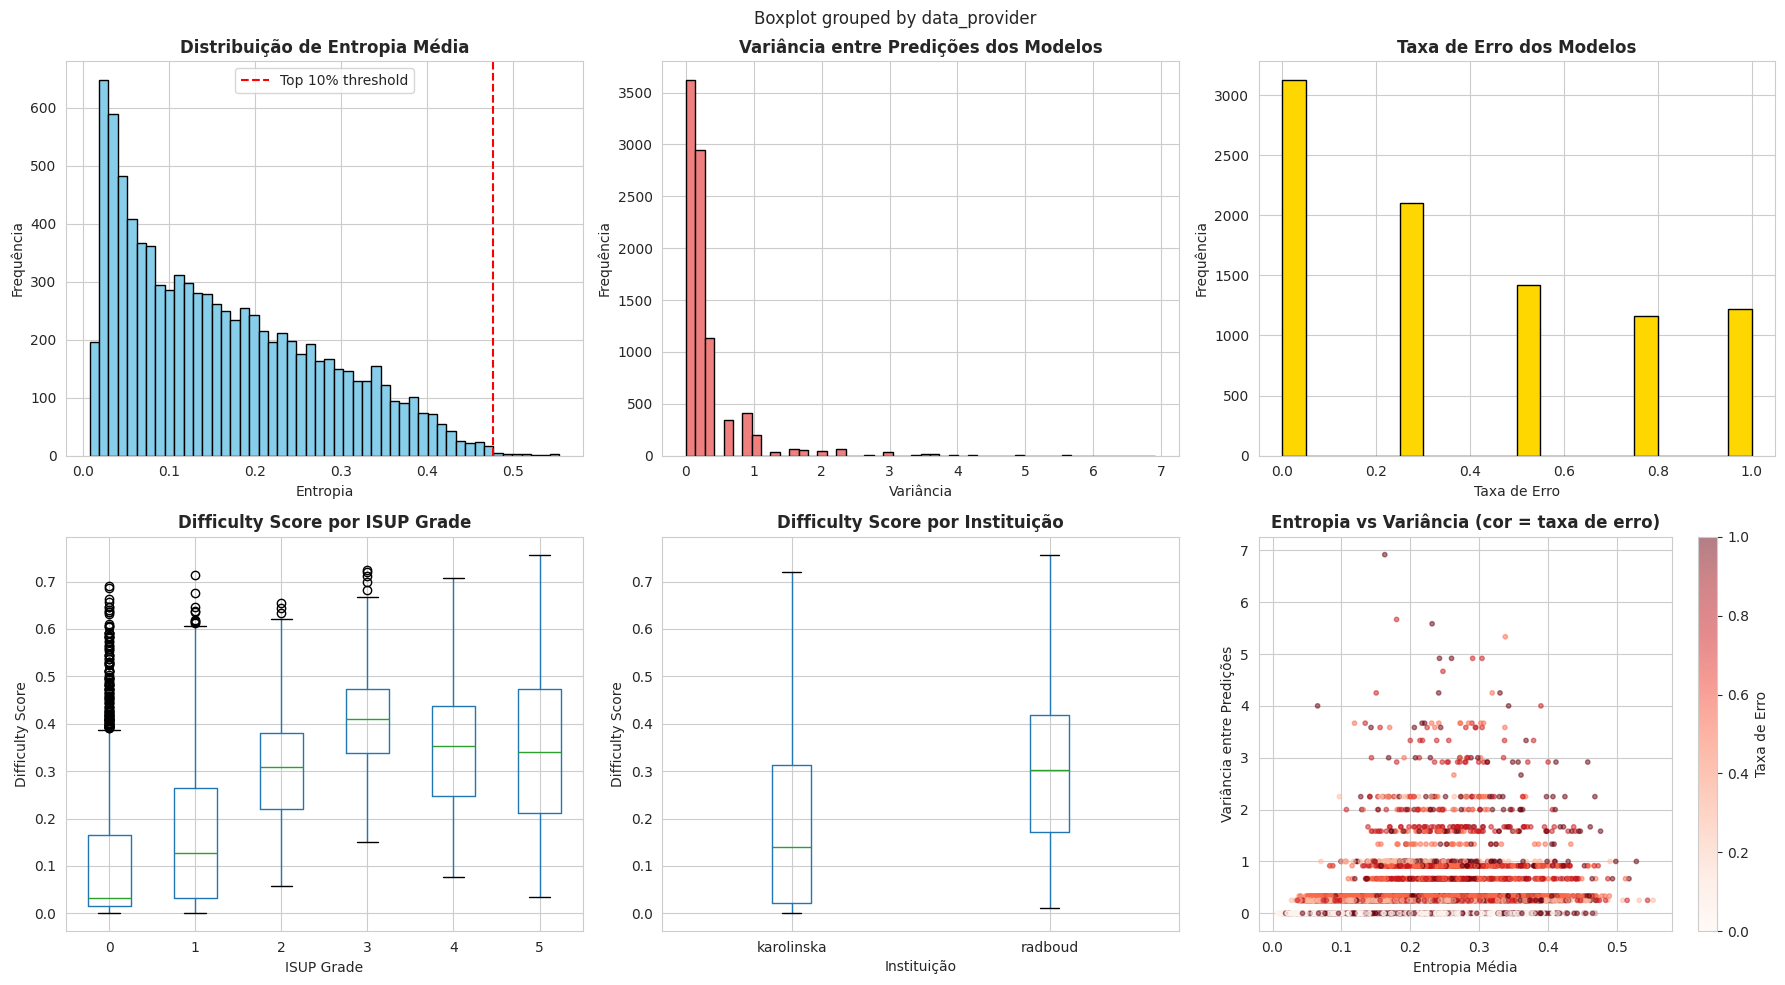

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribuição de entropia
axes[0, 0].hist(analysis_df['mean_entropy'], bins=50, color='skyblue', edgecolor='black')
axes[0, 0].axvline(threshold, color='red', linestyle='--', label=f'Top 10% threshold')
axes[0, 0].set_title('Distribuição de Entropia Média', fontweight='bold')
axes[0, 0].set_xlabel('Entropia')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].legend()

# 2. Distribuição de variância entre modelos
axes[0, 1].hist(analysis_df['prediction_variance'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Variância entre Predições dos Modelos', fontweight='bold')
axes[0, 1].set_xlabel('Variância')
axes[0, 1].set_ylabel('Frequência')

# 3. Taxa de erro
axes[0, 2].hist(analysis_df['error_rate'], bins=20, color='gold', edgecolor='black')
axes[0, 2].set_title('Taxa de Erro dos Modelos', fontweight='bold')
axes[0, 2].set_xlabel('Taxa de Erro')
axes[0, 2].set_ylabel('Frequência')

# 4. Difficulty score por ISUP grade
analysis_df.boxplot(column='difficulty_score', by='isup_grade', ax=axes[1, 0])
axes[1, 0].set_title('Difficulty Score por ISUP Grade', fontweight='bold')
axes[1, 0].set_xlabel('ISUP Grade')
axes[1, 0].set_ylabel('Difficulty Score')
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

# 5. Difficulty score por instituição
analysis_df.boxplot(column='difficulty_score', by='data_provider', ax=axes[1, 1])
axes[1, 1].set_title('Difficulty Score por Instituição', fontweight='bold')
axes[1, 1].set_xlabel('Instituição')
axes[1, 1].set_ylabel('Difficulty Score')

# 6. Correlação entropia vs variância
axes[1, 2].scatter(analysis_df['mean_entropy'], analysis_df['prediction_variance'], 
                   alpha=0.5, c=analysis_df['error_rate'], cmap='Reds', s=10)
axes[1, 2].set_title('Entropia vs Variância (cor = taxa de erro)', fontweight='bold')
axes[1, 2].set_xlabel('Entropia Média')
axes[1, 2].set_ylabel('Variância entre Predições')
cbar = plt.colorbar(axes[1, 2].collections[0], ax=axes[1, 2])
cbar.set_label('Taxa de Erro')

plt.tight_layout()
plt.show()

### 5.3. Matriz de Confusão Agregada

Vamos ver quais classes são mais confundidas entre si.

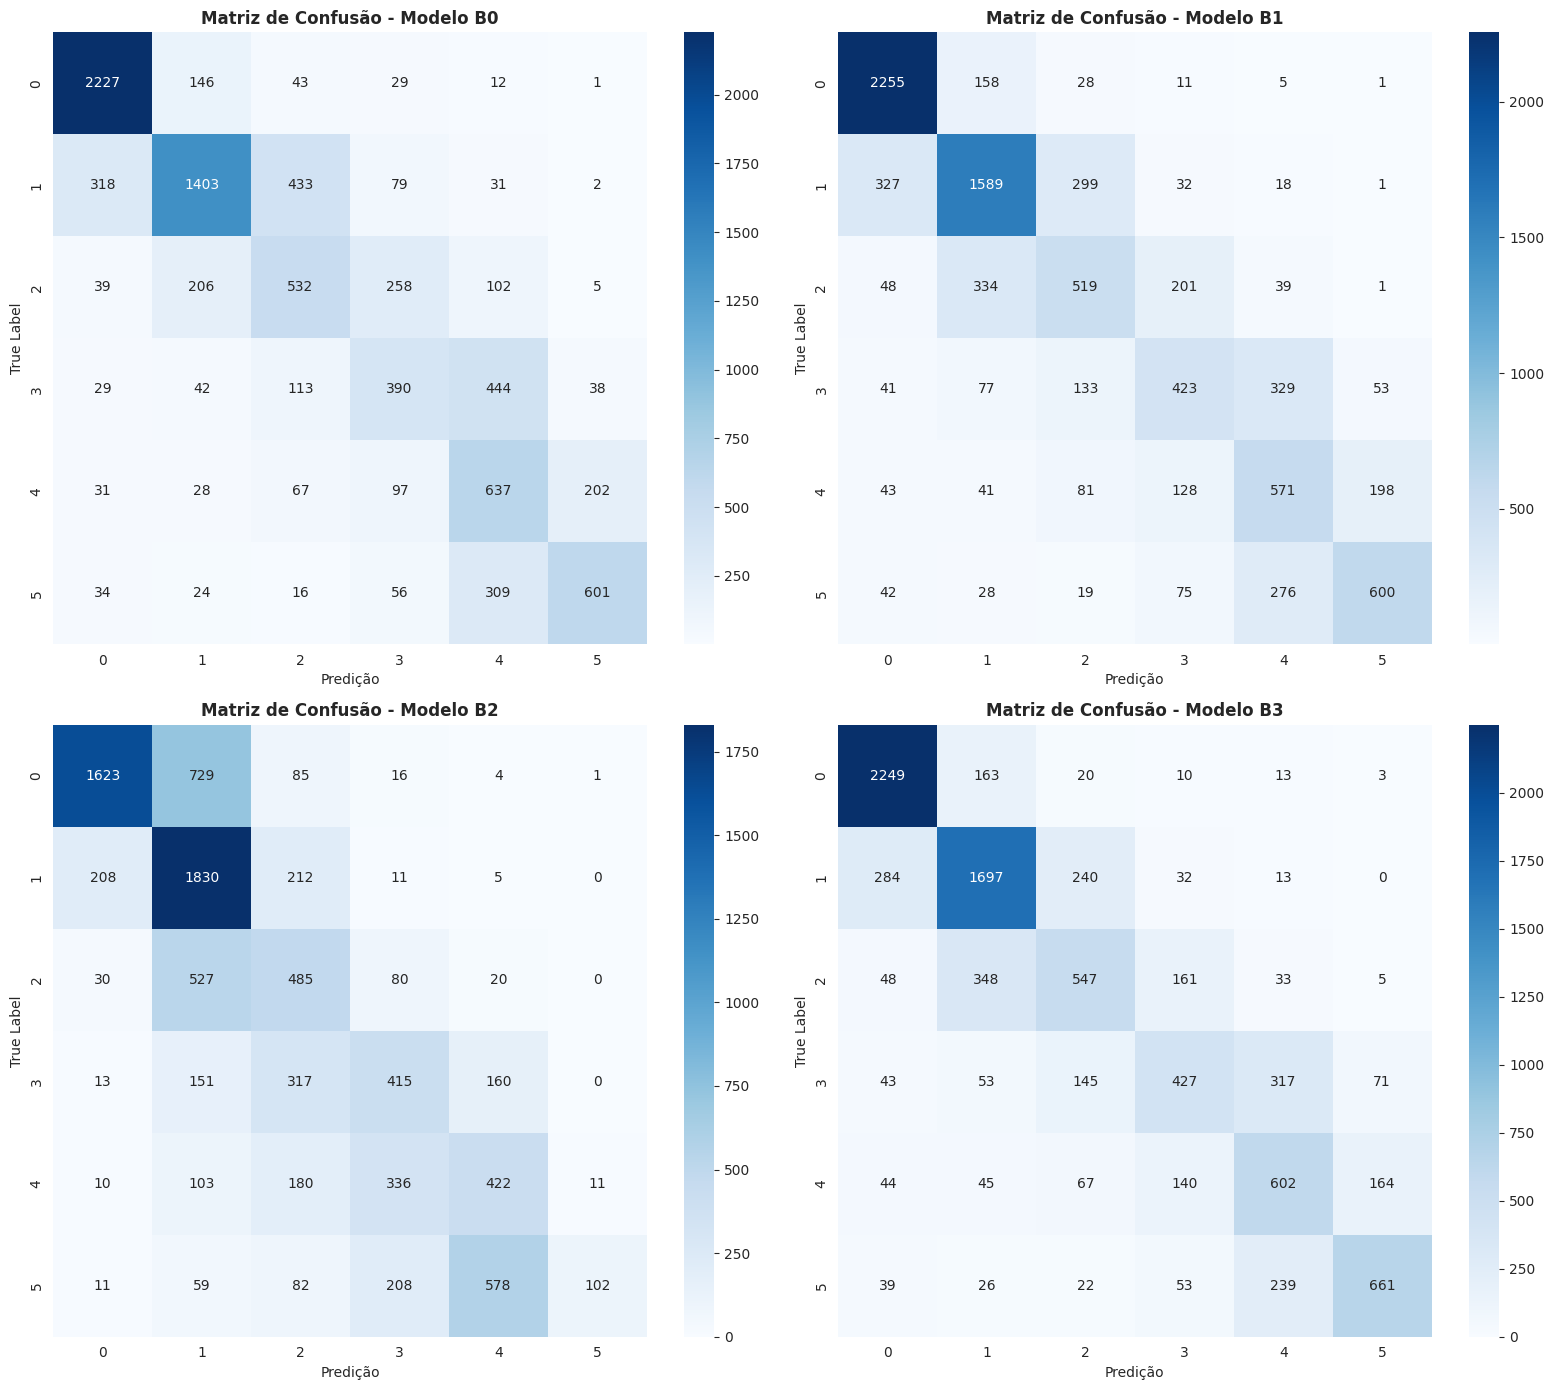

In [24]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, name in enumerate(models.keys()):
    cm = confusion_matrix(analysis_df['true_label'], analysis_df[f'pred_{name}'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=range(6), yticklabels=range(6))
    axes[idx].set_title(f'Matriz de Confusão - Modelo {name.upper()}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Predição')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## 6. Exportar Resultados

Salvar amostras difíceis para análise posterior.

In [25]:
# Salvar top 10% amostras mais difíceis
hard_samples_export = analysis_df.sort_values('difficulty_score', ascending=False).head(int(len(analysis_df) * 0.1))
hard_samples_export.to_csv('logs/difficult_samples.csv', index=False)
print(f"✓ Salvo {len(hard_samples_export)} amostras difíceis em 'logs/difficult_samples.csv'")

# Salvar análise completa
analysis_df.to_csv('logs/complete_analysis.csv', index=False)
print(f"✓ Análise completa salva em 'logs/complete_analysis.csv'")

# Estatísticas resumidas
summary_stats = {
    'total_samples': len(analysis_df),
    'difficult_samples_10pct': len(hard_samples),
    'mean_entropy_all': analysis_df['mean_entropy'].mean(),
    'mean_entropy_difficult': hard_samples['mean_entropy'].mean(),
    'mean_variance_all': analysis_df['prediction_variance'].mean(),
    'mean_variance_difficult': hard_samples['prediction_variance'].mean(),
    'mean_error_rate_all': analysis_df['error_rate'].mean(),
    'mean_error_rate_difficult': hard_samples['error_rate'].mean(),
}

print("\n" + "="*60)
print("RESUMO DA ANÁLISE")
print("="*60)
for key, value in summary_stats.items():
    print(f"{key:30s}: {value:.4f}" if isinstance(value, float) else f"{key:30s}: {value}")

✓ Salvo 902 amostras difíceis em 'logs/difficult_samples.csv'
✓ Análise completa salva em 'logs/complete_analysis.csv'

RESUMO DA ANÁLISE
total_samples                 : 9024
difficult_samples_10pct       : 903
mean_entropy_all              : 0.16097357869148254
mean_entropy_difficult        : 0.3300873041152954
mean_variance_all             : 0.29916515946388245
mean_variance_difficult       : 0.8966407775878906
mean_error_rate_all           : 0.3682
mean_error_rate_difficult     : 0.8915


## 7. Recomendações

Com base na análise:

1. **Amostras com alta dificuldade** devem ser revisadas manualmente para verificar possíveis erros de rotulação
2. **Classes com alta confusão** (ex: 2 vs 3, 3 vs 4) podem se beneficiar de:
   - Mais dados de treino
   - Técnicas de data augmentation específicas
   - Análise de especialistas
3. **Diferenças entre instituições** podem indicar:
   - Viés no dataset
   - Necessidade de normalização/padronização
   - Domain adaptation
4. **Amostras com alto consenso de erro** (todos os modelos erram) são fortes candidatas a:
   - Rótulos incorretos
   - Casos edge/ambíguos que precisam de revisão